Размер датасета: 30000
Распределение меток:
label
0    22973
1     7027
Name: count, dtype: int64

Тестируем на 100 файлах...
Начинаем обработку 100 аудиофайлов...
Применение шумоподавления: True
Обработано 0/100 файлов
Обработка завершена. Успешно: 100, Ошибки: 0
Начинаем обработку 100 аудиофайлов...
Применение шумоподавления: False
Обработано 0/100 файлов
Обработка завершена. Успешно: 100, Ошибки: 0

Результаты:
Признаков с шумоподавлением: (100, 325)
Признаков без шумоподавления: (100, 325)

Визуализация эффекта шумоподавления для файла: train9761.aiff


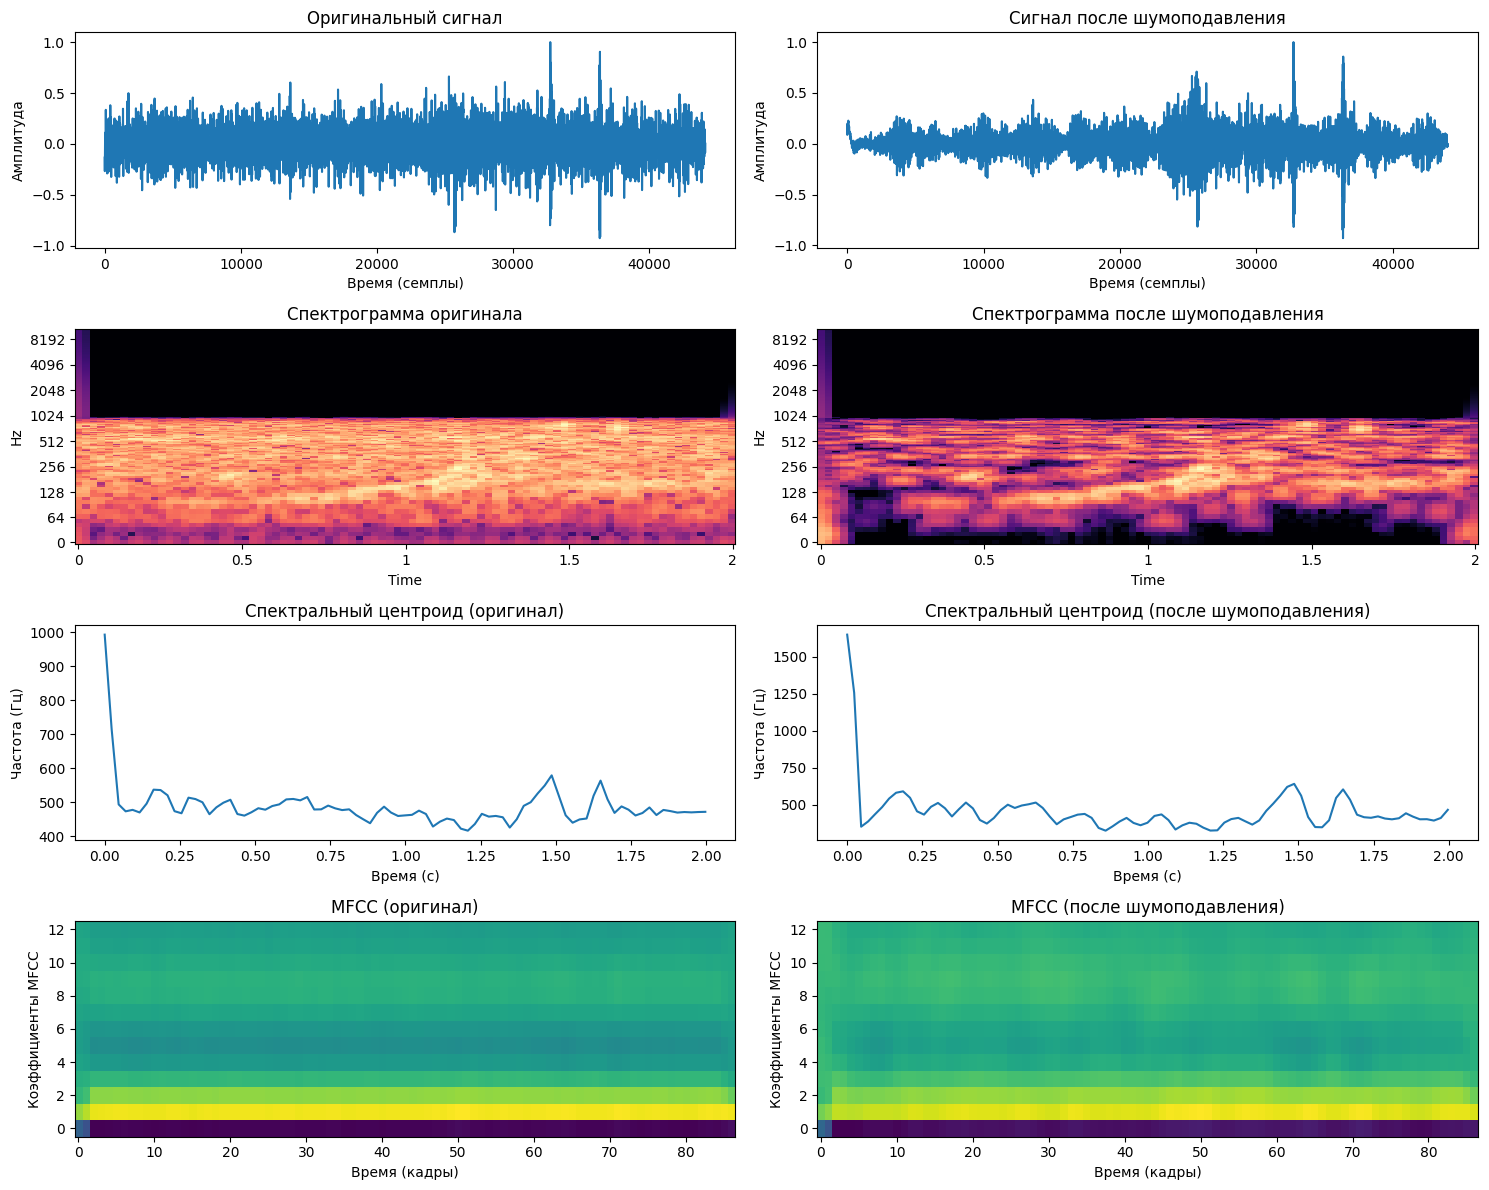

Сравнение метрик:
RMS энергии (оригинал): 0.1671
RMS энергии (после): 0.1258
Zero Crossing Rate (оригинал): 0.0444
Zero Crossing Rate (после): 0.0366


In [1]:
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import butter, filtfilt  # Добавьте эту библиотеку
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
import random
import os
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
from sklearn.model_selection import cross_validate
from pathlib import Path

# Ваша функция шумоподавления
def whale_denoise(y, sr, low_freq=20, high_freq=1000):
    """
    Специализированное шумоподавление для низкочастотных китовых звуков
    """
    try:
        # 1. Bandpass фильтр для частот китов
        def butter_bandpass(lowcut, highcut, fs, order=4):
            nyq = 0.5 * fs
            low = lowcut / nyq
            high = highcut / nyq
            b, a = butter(order, [low, high], btype='band')
            return b, a
        
        b, a = butter_bandpass(low_freq, high_freq, sr)
        y_filtered = filtfilt(b, a, y)
        
        # 2. Spectral subtraction
        D = librosa.stft(y_filtered, n_fft=2048, hop_length=512)
        magnitude = np.abs(D)
        phase = np.angle(D)
        
        # Оценка шума по первым 0.2 секундам
        noise_frames = magnitude[:, :int(0.2 * sr / 512)]
        noise_profile = np.median(noise_frames, axis=1)
        
        # Мягкое spectral subtraction
        threshold = 1.5 * noise_profile.reshape(-1, 1)
        magnitude_clean = np.maximum(magnitude - threshold, 0.001)
        
        # Восстановление сигнала
        D_clean = magnitude_clean * np.exp(1j * phase)
        y_clean = librosa.istft(D_clean)
        
        return y_clean
        
    except Exception as e:
        print(f"Ошибка в шумоподавлении: {e}")
        return y

# Функция для загрузки и предобработки аудио с шумоподавлением
def load_and_preprocess_audio(file_path, apply_denoise=True, target_sr=22050, duration=5):
    """
    Загрузка и предобработка аудиофайла с возможностью шумоподавления
    """
    try:
        # Загрузка аудио
        y, sr = librosa.load(file_path, sr=target_sr, duration=duration)
        
        # Применение шумоподавления
        if apply_denoise:
            y = whale_denoise(y, sr, low_freq=20, high_freq=1000)
        
        # Нормализация
        y = librosa.util.normalize(y)
        
        return y, sr
        
    except Exception as e:
        print(f"Ошибка загрузки файла {file_path}: {e}")
        return None, None

# Функция для извлечения признаков из аудио
def extract_features_from_audio(y, sr, n_mfcc=20, n_mels=128):
    """
    Извлечение признаков из аудиосигнала
    """
    features = {}
    
    # MFCC (Mel-frequency cepstral coefficients)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)
    
    # Mel-spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    mel_mean = np.mean(mel_spec, axis=1)
    mel_std = np.std(mel_spec, axis=1)
    
    # Chroma features
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_mean = np.mean(chroma, axis=1)
    chroma_std = np.std(chroma, axis=1)
    
    # Spectral features
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    
    # Zero crossing rate
    zcr = librosa.feature.zero_crossing_rate(y)
    
    # RMS energy
    rms = librosa.feature.rms(y=y)
    
    # Собираем все признаки в один массив
    features['mfcc_mean'] = mfcc_mean
    features['mfcc_std'] = mfcc_std
    features['mel_mean'] = mel_mean
    features['mel_std'] = mel_std
    features['chroma_mean'] = chroma_mean
    features['chroma_std'] = chroma_std
    features['spectral_centroid'] = np.mean(spectral_centroid)
    features['spectral_bandwidth'] = np.mean(spectral_bandwidth)
    features['spectral_rolloff'] = np.mean(spectral_rolloff)
    features['zcr'] = np.mean(zcr)
    features['rms'] = np.mean(rms)
    
    # Конвертируем в плоский массив
    feature_vector = []
    for key in features:
        if isinstance(features[key], np.ndarray):
            feature_vector.extend(features[key])
        else:
            feature_vector.append(features[key])
    
    return np.array(feature_vector)

# Модифицированная функция для обработки датасета
def process_dataset(df, audio_files_path, apply_denoise=True, max_files=None):
    """
    Обработка всего датасета: загрузка аудио, шумоподавление, извлечение признаков
    """
    features_list = []
    labels_list = []
    failed_files = []
    
    # Ограничиваем количество файлов для тестирования
    if max_files:
        file_subset = audio_files_path[:max_files]
    else:
        file_subset = audio_files_path
    
    print(f"Начинаем обработку {len(file_subset)} аудиофайлов...")
    print(f"Применение шумоподавления: {apply_denoise}")
    
    for i, audio_file in enumerate(file_subset):
        if i % 100 == 0:
            print(f"Обработано {i}/{len(file_subset)} файлов")
        
        # Получаем имя файла для поиска в датафрейме
        filename = audio_file.name
        
        # Ищем метку для этого файла
        label_row = df[df['clip_name'] == filename]
        if label_row.empty:
            print(f"Метка не найдена для файла {filename}")
            continue
        
        label = label_row['label'].values[0]
        
        # Загружаем и обрабатываем аудио
        y, sr = load_and_preprocess_audio(audio_file, apply_denoise=apply_denoise)
        
        if y is not None and sr is not None:
            # Извлекаем признаки
            features = extract_features_from_audio(y, sr)
            features_list.append(features)
            labels_list.append(label)
        else:
            failed_files.append(filename)
    
    print(f"Обработка завершена. Успешно: {len(features_list)}, Ошибки: {len(failed_files)}")
    
    if failed_files:
        print(f"Файлы с ошибками: {failed_files[:10]}")  # Показываем первые 10
        
    return np.array(features_list), np.array(labels_list)

# Визуализация эффекта шумоподавления
def visualize_denoise_effect(file_path):
    """
    Визуализация эффекта шумоподавления на примере одного файла
    """
    # Загрузка оригинального аудио
    y_orig, sr = librosa.load(file_path, sr=22050, duration=5)
    y_orig = librosa.util.normalize(y_orig)
    
    # Применение шумоподавления
    y_denoised = whale_denoise(y_orig.copy(), sr)
    y_denoised = librosa.util.normalize(y_denoised)
    
    # Создание графиков
    fig, axes = plt.subplots(4, 2, figsize=(15, 12))
    
    # 1. Временные сигналы
    axes[0, 0].plot(y_orig)
    axes[0, 0].set_title('Оригинальный сигнал')
    axes[0, 0].set_xlabel('Время (семплы)')
    axes[0, 0].set_ylabel('Амплитуда')
    
    axes[0, 1].plot(y_denoised)
    axes[0, 1].set_title('Сигнал после шумоподавления')
    axes[0, 1].set_xlabel('Время (семплы)')
    axes[0, 1].set_ylabel('Амплитуда')
    
    # 2. Спектрограммы
    D_orig = librosa.amplitude_to_db(np.abs(librosa.stft(y_orig)), ref=np.max)
    librosa.display.specshow(D_orig, sr=sr, x_axis='time', y_axis='log', ax=axes[1, 0])
    axes[1, 0].set_title('Спектрограмма оригинала')
    
    D_denoised = librosa.amplitude_to_db(np.abs(librosa.stft(y_denoised)), ref=np.max)
    librosa.display.specshow(D_denoised, sr=sr, x_axis='time', y_axis='log', ax=axes[1, 1])
    axes[1, 1].set_title('Спектрограмма после шумоподавления')
    
    # 3. Спектральные центроиды
    spectral_centroid_orig = librosa.feature.spectral_centroid(y=y_orig, sr=sr)[0]
    times_orig = librosa.times_like(spectral_centroid_orig)
    
    spectral_centroid_denoised = librosa.feature.spectral_centroid(y=y_denoised, sr=sr)[0]
    times_denoised = librosa.times_like(spectral_centroid_denoised)
    
    axes[2, 0].plot(times_orig, spectral_centroid_orig, label='Спектральный центроид')
    axes[2, 0].set_title('Спектральный центроид (оригинал)')
    axes[2, 0].set_xlabel('Время (с)')
    axes[2, 0].set_ylabel('Частота (Гц)')
    
    axes[2, 1].plot(times_denoised, spectral_centroid_denoised, label='Спектральный центроид')
    axes[2, 1].set_title('Спектральный центроид (после шумоподавления)')
    axes[2, 1].set_xlabel('Время (с)')
    axes[2, 1].set_ylabel('Частота (Гц)')
    
    # 4. MFCC сравнение
    mfcc_orig = librosa.feature.mfcc(y=y_orig, sr=sr, n_mfcc=13)
    mfcc_denoised = librosa.feature.mfcc(y=y_denoised, sr=sr, n_mfcc=13)
    
    axes[3, 0].imshow(mfcc_orig, aspect='auto', origin='lower', cmap='viridis')
    axes[3, 0].set_title('MFCC (оригинал)')
    axes[3, 0].set_xlabel('Время (кадры)')
    axes[3, 0].set_ylabel('Коэффициенты MFCC')
    
    axes[3, 1].imshow(mfcc_denoised, aspect='auto', origin='lower', cmap='viridis')
    axes[3, 1].set_title('MFCC (после шумоподавления)')
    axes[3, 1].set_xlabel('Время (кадры)')
    axes[3, 1].set_ylabel('Коэффициенты MFCC')
    
    plt.tight_layout()
    plt.show()
    
    # Вычисление некоторых метрик для сравнения
    print("Сравнение метрик:")
    print(f"RMS энергии (оригинал): {np.mean(librosa.feature.rms(y=y_orig)):.4f}")
    print(f"RMS энергии (после): {np.mean(librosa.feature.rms(y=y_denoised)):.4f}")
    
    print(f"Zero Crossing Rate (оригинал): {np.mean(librosa.feature.zero_crossing_rate(y_orig)):.4f}")
    print(f"Zero Crossing Rate (после): {np.mean(librosa.feature.zero_crossing_rate(y_denoised)):.4f}")

# Основная часть кода
if __name__ == "__main__":
    # Пути к файлам
    large_data_path = r'F:\\datasets\\whale-detection-challenge\\whale_data\\data' 
    train_path = Path(large_data_path) / 'train'
    test_path = Path(large_data_path) / 'test'
    
    # Метки
    train_csv_path = Path(large_data_path) / 'train.csv'
    train_df = pd.read_csv(train_csv_path)
    train_df = train_df.rename(columns={'clip_name_label': 'filename', 'train1.atif,0': 'label'})
    
    # Получение списков аудиофайлов
    train_audio_files = list(train_path.rglob('*.aiff')) + list(train_path.rglob('*.aif'))
    test_audio_files = list(test_path.rglob('*.aiff')) + list(test_path.rglob('*.aif'))
    
    print(f"Размер датасета: {len(train_df)}")
    print(f"Распределение меток:\n{train_df['label'].value_counts()}")
    
    # Опция для тестирования на небольшом подмножестве
    TEST_MODE = True  # Поставьте False для обработки всего датасета
    APPLY_DENOISE = True  # Применять шумоподавление или нет
    
    if TEST_MODE:
        # Тестирование на небольшом подмножестве
        num_test_files = 100
        print(f"\nТестируем на {num_test_files} файлах...")
        
        # Выбираем случайные файлы для теста
        test_files = random.sample(train_audio_files, min(num_test_files, len(train_audio_files)))
        
        # Обработка с шумоподавлением
        features_denoised, labels_denoised = process_dataset(
            train_df, test_files, apply_denoise=True, max_files=num_test_files
        )
        
        # Обработка без шумоподавления
        features_original, labels_original = process_dataset(
            train_df, test_files, apply_denoise=False, max_files=num_test_files
        )
        
        print(f"\nРезультаты:")
        print(f"Признаков с шумоподавлением: {features_denoised.shape}")
        print(f"Признаков без шумоподавления: {features_original.shape}")
        
        # Визуализация эффекта шумоподавления на одном файле
        if len(test_files) > 0:
            sample_file = test_files[0]
            print(f"\nВизуализация эффекта шумоподавления для файла: {sample_file.name}")
            visualize_denoise_effect(sample_file)
        
    else:
        # Полная обработка датасета
        print("\nЗапуск полной обработки датасета...")
        
        # Обработка тренировочных данных с шумоподавлением
        X_train, y_train = process_dataset(
            train_df, train_audio_files, apply_denoise=APPLY_DENOISE
        )
        
        # Сохранение обработанных данных
        if len(X_train) > 0 and len(y_train) > 0:
            np.save('X_train_features.npy', X_train)
            np.save('y_train_labels.npy', y_train)
            print(f"\nДанные сохранены:")
            print(f"X_train: {X_train.shape}")
            print(f"y_train: {y_train.shape}")
            
            # Можно продолжить с обучением модели
            # ... (ваш существующий код для обучения моделей)